In [2]:
import pandas as pd

df = pd.read_csv('../data/us_comic.csv')
df

,index,comic_book_store_name,address,city,state,latitude,longitude
0,0,Albertville Candy Shop,118 E. Main St.,Albertville,AL,34.267369,-86.207686
1,1,All American Sports Cards and Comics,106 S. Water St.,Tuscumbia,AL,34.732331,-87.705093
2,2,All Star Comics & Cards,58 N. Main St.,Arab,AL,34.317467,-86.495688
3,3,Big Hit Sports Cards,6450 Hwy. 90 #L.,Spanish Fort,AL,30.721340,-87.865999
4,4,Bob's Comics,979 Gadsden Hwy.,Birmingham,AL,33.586211,-86.661340
...,...,...,...,...,...,...,...
2244,2244,Heroes Only Comics & Games,3151 Nationway #K5,Cheyenne,WY,41.131947,-104.776243
2245,2245,Heros Comics & Sportscards,20 W. Broadway,Jackson,WY,43.479264,-110.762713
2246,2246,The Card Kid Inc.,2510 Warren Ave. #3170,Cheyenne,WY,41.141808,-104.818833
2247,2247,The First Resort,214 N. Main St.,Sheridan,WY,44.799844,-106.956226


In [3]:
# Pilih kolom yang relevan untuk clustering geografis
df_clustering = df[['latitude', 'longitude']].copy()

# Cek duplikasi 
print(f"Jumlah duplikasi baris: {df_clustering.duplicated().sum()}")

Jumlah duplikasi baris: 164


In [4]:
df_clustering.drop_duplicates(inplace=True)

In [5]:
from sklearn.preprocessing import RobustScaler
import numpy as np

# Data yang akan di-scaling
X = df_clustering.values

# Inisialisasi dan terapkan RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Konversi kembali ke DataFrame untuk memudahkan
df_scaled = pd.DataFrame(X_scaled, columns=['latitude_scaled', 'longitude_scaled'])

print(df_scaled.head())

   latitude_scaled  longitude_scaled
0        -0.817543         -0.004459
1        -0.748126         -0.082365
2        -0.810063         -0.019443
3        -1.346950         -0.090736
4        -0.919237         -0.028062


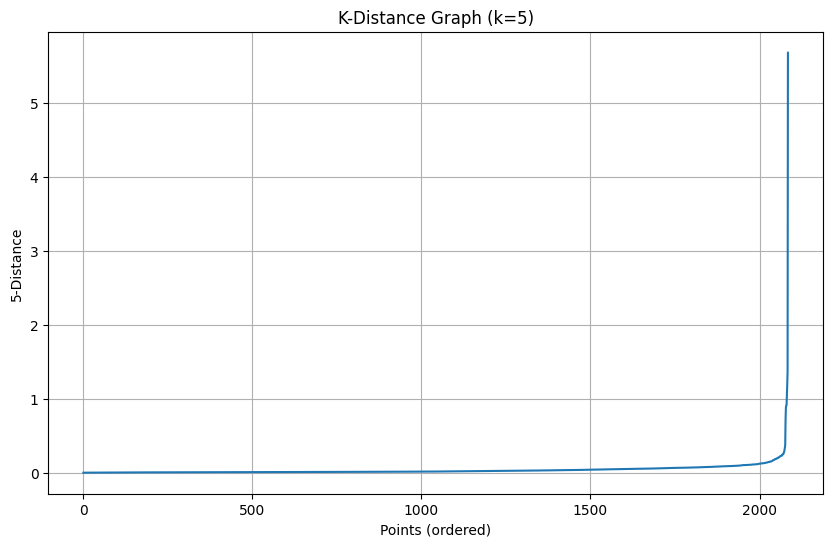

In [6]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

k = 5 # Jumlah tetangga (MinPts)
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Ambil jarak ke tetangga ke-(k-1), lalu diurutkan
k_distances = np.sort(distances[:, k-1], axis=0)

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title(f"K-Distance Graph (k={k})")
plt.ylabel(f"{k}-Distance")
plt.xlabel("Points (ordered)")
plt.grid(True)
plt.show()

# Tugas Anda: Amati grafik dan tentukan nilai epsilon (epsilon) di titik elbow
# Misalnya, nilai yang Anda pilih adalah 'eps_optimal' = 0.5 (hanya contoh)
# eps_optimal = ...

In [8]:
from sklearn.cluster import DBSCAN

df_unique = df[['latitude', 'longitude']].drop_duplicates().reset_index(drop=True)
X = df_unique.values
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# --- LANGKAH 4. Clustering dengan DBSCAN (KODE PERBAIKAN) ---

# Ganti nilai 0.5 
eps_optimal = 0.5  

dbscan = DBSCAN(eps=eps_optimal, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# 4a. Tambahkan label ke DataFrame yang sudah di-deduplicate (2085 baris)
df_unique['Cluster_DBSCAN'] = labels

df = df.merge(
    df_unique[['latitude', 'longitude', 'Cluster_DBSCAN']],
    on=['latitude', 'longitude'],
    how='left'
)

# 4c. Hapus kolom 'Cluster_DBSCAN_x' 
if 'Cluster_DBSCAN_x' in df.columns:
    df.drop(columns=['Cluster_DBSCAN_x'], inplace=True)
# Ubah nama kolom hasil merge yang benar
df.rename(columns={'Cluster_DBSCAN_y': 'Cluster_DBSCAN'}, inplace=True)


# Hitung jumlah anggota di setiap cluster (Total harus 2249)
print(df['Cluster_DBSCAN'].value_counts())
print(f"Total baris di df: {len(df)}")

Cluster_DBSCAN
 0    2188
-1      51
 1      10
Name: count, dtype: int64
Total baris di df: 2249


In [9]:
from sklearn.metrics import silhouette_score

# Hapus noise (-1) sebelum menghitung Silhouette Score
mask = labels != -1
if np.unique(labels[mask]).size > 1:
    score = silhouette_score(X_scaled[mask], labels[mask])
    print(f"Silhouette Score: {score:.4f}")
else:
    print("Hanya satu cluster (atau tidak ada cluster selain noise) yang tersisa. Silhouette Score tidak dapat dihitung.")

# Interpretasi: Skor 0.5 - 0.7 dianggap "Cukup Baik" untuk DBSCAN.

Silhouette Score: 0.6836


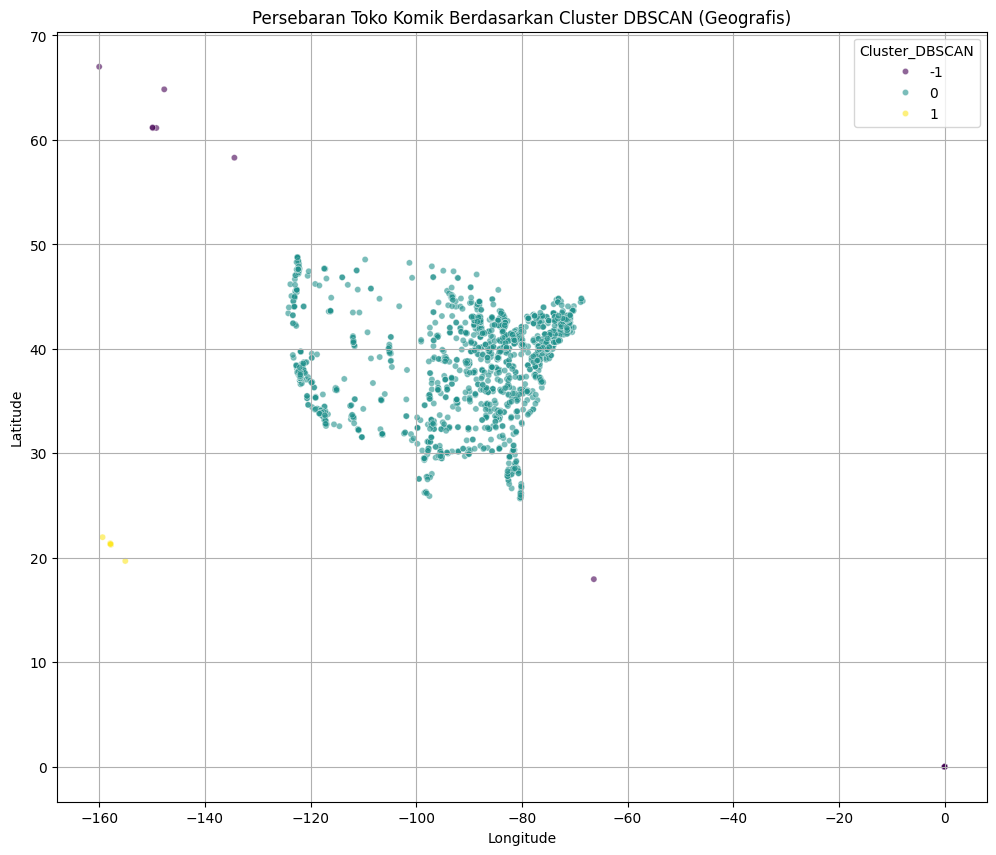

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='longitude', 
    y='latitude', 
    hue='Cluster_DBSCAN', 
    data=df, 
    palette='viridis', 
    legend='full',
    alpha=0.6,
    s=20 # Ukuran titik
)
plt.title('Persebaran Toko Komik Berdasarkan Cluster DBSCAN (Geografis)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

In [11]:
# Cek 5 lokasi teratas di Cluster Noise (-1) untuk identifikasi outlier
print("\nTop 5 Lokasi Noise (Outlier):")
noise_locations = df[df['Cluster_DBSCAN'] == -1]
print(noise_locations[['comic_book_store_name', 'city', 'state']].head(5))

# Cek distribusi State/Kota di cluster terbesar (misalnya Cluster 0)
print("\nDistribusi State di Cluster 0:")
print(df[df['Cluster_DBSCAN'] == 0]['state'].value_counts().head(5))


Top 5 Lokasi Noise (Outlier):
                 comic_book_store_name       city state
29  A No 1 Cards Comics & Collectibles  Anchorage    AK
30        Bosco's Comics Cards & Games  Anchorage    AK
31        Bosco's Comics Cards & Games  Anchorage    AK
32                Collector's Hideaway     Juneau    AK
33                      The Comic Shop  Fairbanks    AK

Distribusi State di Cluster 0:
state
CA    201
NY    151
TX    137
OH    130
IL    121
Name: count, dtype: int64
